<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 9</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Réseaux de neurones artificiels</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : perceptron simple, perceptron multicouche avec `scikit-learn` puis Keras, et perceptron multicouche profond. Il permet également de régénérer les figures associées selon les conventions graphiques du livre. Les schémas d'architecture (perceptron, MLP, étapes d'entraînement et propagation avant) sont réalisés avec un autre logiciel et ne figurent pas dans ce carnet. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `matplotlib`, `scikit-learn` (≥ 1.6), `tensorflow` (≥ 2.16, qui fournit Keras) et `networkx`.  
**Installation complémentaire** : au besoin, `tensorflow` et `networkx` s'installent avec `pip install tensorflow networkx`.  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration ; l'entraînement des modèles Keras prend moins d'une minute.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import tensorflow as tf

PAQUETS = ('numpy', 'matplotlib', 'scikit-learn', 'tensorflow', 'networkx')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Couleurs du livre (palette viridis)
VIOLET   = '#482878'
SARCELLE = '#21918c'
VERT     = '#5ec962'
BLEU     = '#3b528b'    # couche d'entrée / nuages de données
MAGENTA  = '#bf00bf'    # courbes de modèle

# Couleurs des bordures
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}

# Couleurs des zones de décision
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
matplotlib         3.11.0
scikit-learn       1.9.0
tensorflow         2.21.0
networkx           3.6.1


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#127924;</span> Figure : Fonctions d'activation binaires — (a) Heaviside et (b) signe</h3>

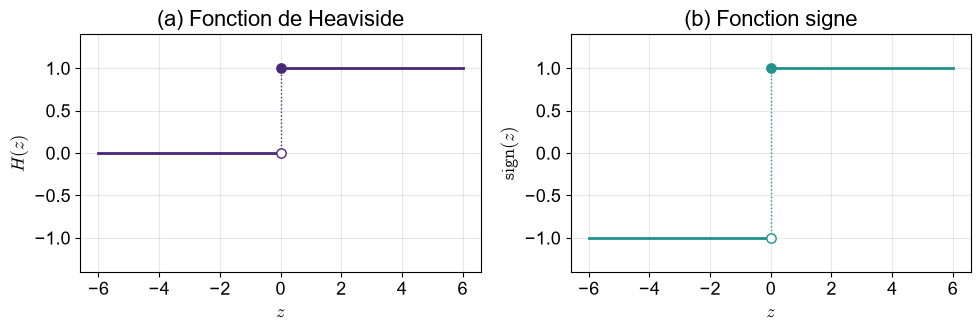

In [3]:
# Figure Fig_Chap9_ActivationsBinaires
x = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# (a) Heaviside : discontinuité en 0 (H(0) = 1)
axes[0].plot([-6, 0], [0, 0], color=VIOLET, linewidth=2)
axes[0].plot([0, 6], [1, 1], color=VIOLET, linewidth=2)
axes[0].plot([0, 0], [0, 1], color=VIOLET, linewidth=1, linestyle=':')
axes[0].scatter([0], [1], s=45, c=VIOLET, zorder=3)
axes[0].scatter([0], [0], s=45, facecolors='white', edgecolors=VIOLET, zorder=3)
axes[0].set_title('(a) Fonction de Heaviside')
axes[0].set_ylabel('$H(z)$')
axes[0].set_ylim(-1.4, 1.4)

# (b) signe
axes[1].plot([-6, 0], [-1, -1], color=SARCELLE, linewidth=2)
axes[1].plot([0, 6], [1, 1], color=SARCELLE, linewidth=2)
axes[1].plot([0, 0], [-1, 1], color=SARCELLE, linewidth=1, linestyle=':')
axes[1].scatter([0], [1], s=45, c=SARCELLE, zorder=3)
axes[1].scatter([0], [-1], s=45, facecolors='white', edgecolors=SARCELLE, zorder=3)
axes[1].set_title('(b) Fonction signe')
axes[1].set_ylabel('$\\mathrm{sign}(z)$')
axes[1].set_ylim(-1.4, 1.4)

for ax in axes:
    ax.set_xlabel('$z$')
    ax.grid(alpha=0.3)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap9_ActivationsBinaires')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.1 : Lecture et préparation des données <i>Iris</i> pour une classification binaire</h3>

In [4]:
from sklearn import datasets

# Chargement du jeu de données Iris
iris = datasets.load_iris()

# Sélection des deux variables explicatives : longueur et largeur des pétales
X = iris.data[:, (2, 3)]  # colonnes 'petal length' et 'petal width'

# Création des étiquettes binaires : 1 pour 'Setosa', 0 pour les autres espèces
y = (iris.target == 0).astype(int)

<h3><span style="font-size: 30px">&#127924;</span> Figure : Le jeu de données <i>Iris</i> organisé en deux classes</h3>

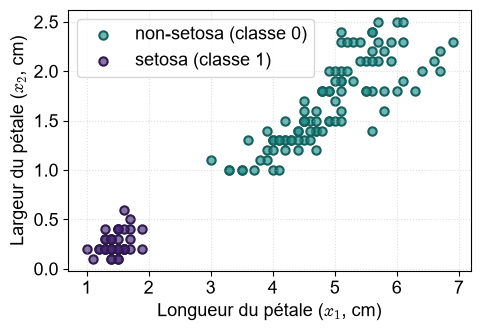

In [5]:
# Figure Fig_Chap9_IrisDeuxClasses : setosa (classe 1) vs non-setosa (classe 0)
from matplotlib.colors import to_rgba

fig, ax = plt.subplots(figsize=(5, 3.5))

for val, nom, coul in [(0, 'non-setosa (classe 0)', SARCELLE),
                       (1, 'setosa (classe 1)', VIOLET)]:
    idx = (y == val)
    ax.scatter(X[idx, 0], X[idx, 1], color=to_rgba(coul, 0.65),
               edgecolors=BORD[coul], linewidths=1.5, label=nom)

ax.set_xlabel('Longueur du pétale ($x_1$, cm)')
ax.set_ylabel('Largeur du pétale ($x_2$, cm)')
ax.grid(alpha=0.4, linestyle=':')
ax.legend(loc='upper left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap9_IrisDeuxClasses')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.2 : Création et entraînement d'un perceptron simple avec scikit-learn</h3>

In [6]:
from sklearn.linear_model import Perceptron

# Initialisation et entraînement du Perceptron
per_clf = Perceptron(max_iter=100, tol=1e-3, random_state=42)
per_clf.fit(X, y)

# Valeur de la constante
intercept = per_clf.intercept_[0]

# Les poids des caractéristiques petal length (x1) et petal width (x2)
coefficients = per_clf.coef_[0]

# Affichage des paramètres appris
print("intercept_ :", intercept)
print("coef_ :", coefficients)

intercept_ : 4.0
coef_ : [-1.4 -2.2]


<h3><span style="font-size: 30px">&#127924;</span> Figure : Frontière de décision du perceptron (deux classes)</h3>

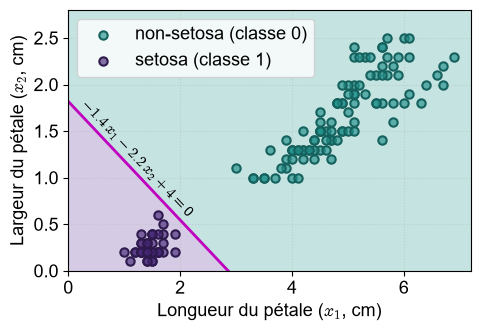

In [7]:
# Figure Fig_Chap9_FrontiereDeuxClasses : zones de décision du perceptron
from matplotlib.colors import to_rgba

x1_min, x1_max, x2_min, x2_max = 0, 7.2, 0, 2.8
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 500),
                     np.linspace(x2_min, x2_max, 500))
Z = per_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5],
            cmap=ListedColormap([ZONE[SARCELLE], ZONE[VIOLET]]), zorder=0)

# frontière : w1*x1 + w2*x2 + b = 0
pente = -coefficients[0] / coefficients[1]
ordonnee = -intercept / coefficients[1]
xs = np.array([x1_min, x1_max])
ax.plot(xs, pente * xs + ordonnee, color=MAGENTA, linewidth=2, zorder=2)

# Équation de la frontière, inscrite le long de la droite
x_eq = 0.18
y_eq = pente * x_eq + ordonnee
ax.text(x_eq, y_eq + 0.05, r'$-1.4\,x_1 - 2.2\,x_2 + 4 = 0$',
        rotation=np.degrees(np.arctan(pente)), transform_rotates_text=True,
        rotation_mode='anchor', ha='left', va='bottom', fontsize=11, zorder=4)

for val, nom, coul in [(0, 'non-setosa (classe 0)', SARCELLE),
                       (1, 'setosa (classe 1)', VIOLET)]:
    idx = (y == val)
    ax.scatter(X[idx, 0], X[idx, 1], color=to_rgba(coul, 0.65),
               edgecolors=BORD[coul], linewidths=1.5, label=nom, zorder=3)

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_xlabel('Longueur du pétale ($x_1$, cm)')
ax.set_ylabel('Largeur du pétale ($x_2$, cm)')
ax.grid(alpha=0.4, linestyle=':')
ax.legend(loc='upper left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap9_FrontiereDeuxClasses')

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Fonctions d'activation — (a) sigmoïde, (b) ReLU et (c) tanh</h3>

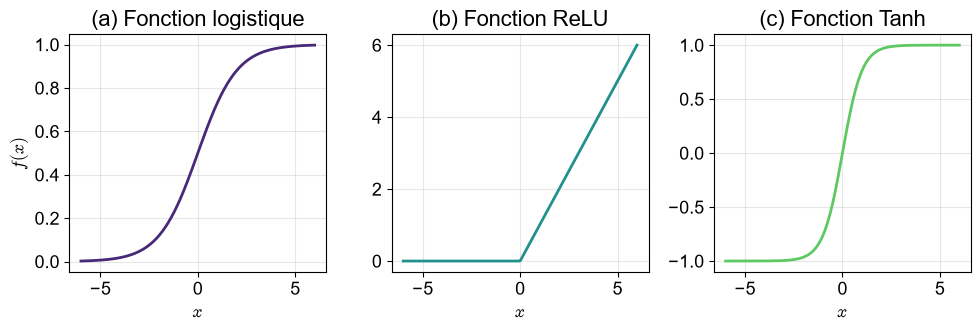

In [8]:
# Figure Fig_Chap9_Activations
x = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].plot(x, 1 / (1 + np.exp(-x)), color=VIOLET, linewidth=2)
axes[0].set_title('(a) Fonction logistique')
axes[0].set_ylabel('$f(x)$')
axes[1].plot(x, np.maximum(0, x), color=SARCELLE, linewidth=2)
axes[1].set_title('(b) Fonction ReLU')
axes[2].plot(x, np.tanh(x), color=VERT, linewidth=2)
axes[2].set_title('(c) Fonction Tanh')
for ax in axes:
    ax.set_xlabel('$x$')
    ax.grid(alpha=0.3)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap9_Activations')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.3 : Partition et standardisation des données</h3>

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Limitation de l'analyse aux variables "petal length" et "petal width"
X = iris.data[:, 2:4]
y = iris.target

# Noms des classes: setosa, versicolor, virginica
class_names = iris.target_names  

# Diviser les données en ensemble d'entraînement et de test (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)

# Mise à l'échelle des données après répartition des données entraînement/test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.4 : Création et entraînement d'un perceptron multicouche avec scikit-learn</h3>

In [10]:
from sklearn.neural_network import MLPClassifier

# Initialisation du classificateur MLP
# Deux couches cachées avec 3 et 6 neurones et une  fonction d'activation ReLU
mlp = MLPClassifier(max_iter=1000, 
                    hidden_layer_sizes=(3, 6),  
                    activation='relu',         
                    learning_rate_init=0.01,
                    random_state=42)

# Entraînement du modèle
mlp.fit(X_train, y_train)

# Exactitude sur l'ensemble de test
print("Exactitude test :", round(mlp.score(X_test, y_test), 4))

Exactitude test : 0.9333


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.5 : Visualisation des frontières de décision par une carte de contours</h3>

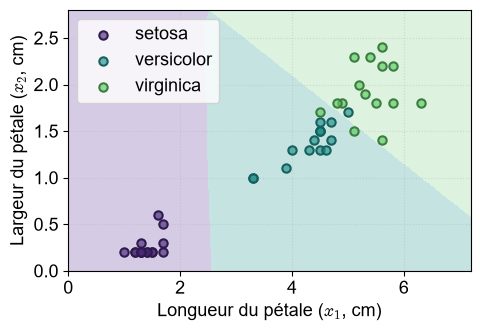

In [11]:
from matplotlib.colors import ListedColormap, to_rgba

# Calculer les limites pour la frontière de décision
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Création d'un maillage de points pour la surface de décision
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500))

# Prédiction des classes pour chaque point du maillage
Z = mlp.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Colormap des zones de décision : couleurs pâles des trois espèces
custom_cmap = ListedColormap([ZONE[VIOLET], ZONE[SARCELLE], ZONE[VERT]])

# Création de la figure et des axes
fig, ax = plt.subplots(figsize=(5, 3.5))

# Affichage de la frontière de décision
ax.contourf(xx, yy, Z, cmap=custom_cmap)

# Tracé des points de test (coordonnées d'origine), colorés selon leur classe réelle
X_test_orig = scaler.inverse_transform(X_test)
couleurs = [VIOLET, SARCELLE, VERT]

for k, (nom, coul) in enumerate(zip(class_names, couleurs)):
    ax.scatter(X_test_orig[y_test == k, 0], X_test_orig[y_test == k, 1],
               color=to_rgba(coul, 0.65), edgecolors=BORD[coul],
               linewidths=1.5, label=nom, zorder=3)

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_xlabel('Longueur du pétale ($x_1$, cm)')
ax.set_ylabel('Largeur du pétale ($x_2$, cm)')
ax.tick_params(axis='both')
ax.grid(alpha=0.4, linestyle=':')
ax.legend(loc='upper left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap9_FrontieresTroisClasses')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.6 : Création et entraînement d'un perceptron multicouche avec Keras</h3>

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

# Définition du modèle MLP avec Keras
model = Sequential()

# Couche d'entrée (vecteurs de caractéristiques à deux dimensions)
model.add(Input(shape=(2,)))

# Première couche cachée (3 neurones, activation ReLU)
model.add(Dense(3, activation='relu'))

# Deuxième couche cachée (6 neurones, activation ReLU)
model.add(Dense(6, activation='relu'))

# Couche de sortie (softmax pour la classification multi-classes)
model.add(Dense(3, activation='softmax'))

# Compilation du modèle
model.compile(optimizer=SGD(learning_rate=0.01), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(X_train, y_train, epochs=50, batch_size=8,
                    validation_split=0.1, verbose=0)

# Évaluation sur l'ensemble de test
perte, exactitude = model.evaluate(X_test, y_test, verbose=0)
print("Exactitude test :", round(exactitude, 4))

Exactitude test : 0.9333


<h3><span style="font-size: 30px">&#127924;</span> Figure : Visualisation des connexions synaptiques du réseau</h3>

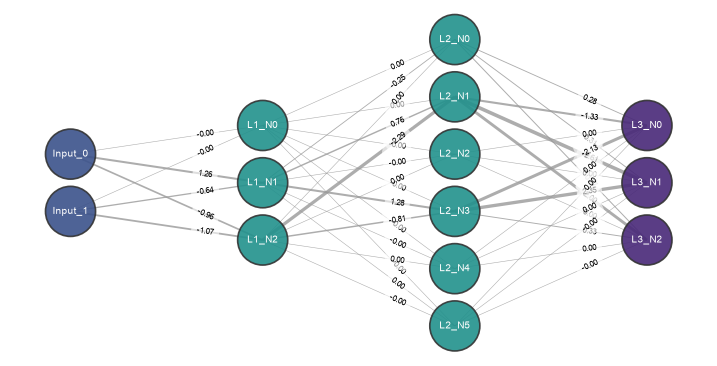

Amplitude moyenne des poids issus de Input_0 : 0.741
Amplitude moyenne des poids issus de Input_1 : 0.57


In [13]:
# Figure Fig_Chap9_PoidsSynaptiques : graphe du MLP scikit-learn (NetworkX)
import networkx as nx

G = nx.DiGraph()
tailles = [mlp.coefs_[0].shape[0]] + [w.shape[1] for w in mlp.coefs_]
noms_couches = [[f'Input_{i}' for i in range(tailles[0])]] + \
               [[f'L{l}_N{j}' for j in range(n)] for l, n in enumerate(tailles[1:], start=1)]
pos, couleurs_noeuds = {}, []

palette = [BLEU] + [SARCELLE] * (len(tailles) - 2) + [VIOLET]
for l, (noms, coul) in enumerate(zip(noms_couches, palette)):
    decal = (len(noms) - 1) / 2
    for j, nom in enumerate(noms):
        G.add_node(nom)
        pos[nom] = (l * 3, decal - j)
        couleurs_noeuds.append(coul)
etiquettes_aretes = {}
for l, W in enumerate(mlp.coefs_):
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            G.add_edge(noms_couches[l][i], noms_couches[l + 1][j], poids=W[i, j])
            etiquettes_aretes[(noms_couches[l][i], noms_couches[l + 1][j])] = f'{W[i, j]:.2f}'

fig, ax = plt.subplots(figsize=(9, 4.5))

largeurs = [0.4 + 2.2 * abs(G[u][v]['poids']) / max(abs(w) for _, _, w in G.edges.data('poids'))
            for u, v in G.edges]
nx.draw_networkx_edges(G, pos, ax=ax, width=largeurs, edge_color='0.6',
                       arrows=False, alpha=0.8)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1300, node_color=couleurs_noeuds,
                       edgecolors='0.2', linewidths=1.2, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color='white')
nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=etiquettes_aretes,
                             font_size=6, label_pos=0.72,
                             bbox=dict(alpha=0.6, facecolor='white', edgecolor='none'))
ax.axis('off')

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap9_PoidsSynaptiques')

plt.show()

# Complément : amplitude moyenne des connexions issues de chaque entrée
for i in range(mlp.coefs_[0].shape[0]):
    print(f'Amplitude moyenne des poids issus de Input_{i} :',
          round(np.abs(mlp.coefs_[0][i]).mean(), 3))

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.7 : Préparation des données pour la classification multiclasse (encodage one-hot)</h3>

In [14]:
from sklearn.preprocessing import OneHotEncoder

# L'analyse est limitée aux variables "petal length" et "petal width"
X, y = iris.data[:, 2:4], iris.target

# Encodage des étiquettes en one-hot
encoder  = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# Division en ensembles d'entraînement et de test (70 % train, 30 % test)
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.3,
                                                    random_state=42, stratify=y)

# Standardisation après la séparation entraînement/test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.8 : Création et entraînement d'un perceptron multicouche profond avec Keras</h3>

In [15]:
# Définition du modèle mlp_profond. Le nom "MLP_Profond" s'affichera dans le résumé
mlp_profond = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu', name='dense_256'),
        Dense(128, activation='relu', name='dense_128'),
        Dense(64, activation='relu', name='dense_64'),
        Dense(32, activation='relu', name='dense_32'),
        Dense(16, activation='relu', name='dense_16'),
        Dense(y_onehot.shape[1], activation='softmax', name='sortie')
], name="MLP_Profond")

# Compilation du modèle
mlp_profond.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Entraînement du modèle uniquement sur l'ensemble d'entraînement
history = mlp_profond.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0)

# Évaluation finale sur l'ensemble de test
perte, exactitude = mlp_profond.evaluate(X_test, y_test, verbose=0)
print("Exactitude test :", round(exactitude, 4))

# Affichage du résumé du modèle
mlp_profond.summary()

Exactitude test : 0.9333


Model: "MLP_Profond"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_256 (Dense)               │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,739 (522.42 KB)

 Trainable params: 44,579 (174.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 89,160 (348.29 KB)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 9.9 : Création d'un perceptron multicouche profond avec Keras à l'aide d'une liste de couches cachées</h3>

In [16]:
# Liste des dimensions des couches cachées
hidden_layers = [256, 128, 64, 32, 16] 

# Création du modèle séquentiel
model = Sequential(name="MLP_Profond_Boucle")
model.add(Input(shape=(X_train.shape[1],)))

# Ajout dynamique des couches cachées à l'aide d'une boucle
for units in hidden_layers:
    model.add(Dense(units, activation='relu', name=f'dense_{units}'))

# Couche de sortie (softmax pour la classification multi-classes)
model.add(Dense(y_onehot.shape[1], activation='softmax', name='sortie'))

# Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle uniquement sur l'ensemble d'entraînement
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=8,
                    verbose=0)

# Évaluation finale sur l'ensemble de test
perte, exactitude = model.evaluate(X_test, y_test, verbose=0)
print("Exactitude test :", round(exactitude, 4))

# Affichage du résumé du modèle
model.summary()

Exactitude test : 0.9333


Model: "MLP_Profond_Boucle"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_256 (Dense)               │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,739 (522.42 KB)

 Trainable params: 44,579 (174.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 89,160 (348.29 KB)

<hr style='border-top:4px solid #1F77B4;'>